# Anàlisi de Monstres de Dungeons & Dragons 5e

Aquest notebook aplica i compara els principals models de machine learning sobre el dataset de monstres de D&D 5e.

**Dataset:** `dnd_monsters.csv` — 762 monstres amb atributs com HP, AC, CR, estadístiques (STR, DEX, CON, INT, WIS, CHA), tipus, mida i alineació.

**Models aplicats:**
1. Naive Bayes — Classificació del tipus de monstre
2. Arbre de Decisions — Classificació del bracket de dificultat (CR)
3. K-Nearest Neighbors (KNN) — Classificació del bracket de dificultat (CR)
4. Perceptró — Classificació binària: és llegendari?
5. Xarxa Neuronal (MLP) — Classificació de la mida del monstre

## 1. Importació de llibreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('models', exist_ok=True)
os.makedirs('static/img', exist_ok=True)

print('Llibreries carregades correctament.')

Llibreries carregades correctament.


## 2. Càrrega i exploració del dataset

In [2]:
def parse_cr(cr):
    """Converteix fraccions de CR (1/4, 1/2) a float."""
    if pd.isna(cr):
        return np.nan
    if isinstance(cr, str) and '/' in cr:
        num, den = cr.split('/')
        return float(num) / float(den)
    return float(cr)

df = pd.read_csv('data/dnd_monsters.csv')
df['cr'] = df['cr'].apply(parse_cr)

print(f'Forma del dataset: {df.shape}')
print(f'\nColumnes: {df.columns.tolist()}')
df.head(10)

Forma del dataset: (762, 17)

Columnes: ['name', 'url', 'cr', 'type', 'size', 'ac', 'hp', 'speed', 'align', 'legendary', 'source', 'str', 'dex', 'con', 'int', 'wis', 'cha']


,name,url,cr,type,size,ac,hp,speed,align,legendary,source,str,dex,con,int,wis,cha
0,aarakocra,https://www.aidedd.org/dnd/monstres.php?vo=aar...,0.25,humanoid (aarakocra),Medium,12,13,fly,neutral good,NaN,Monster Manual (BR),10.0,14.0,10.0,11.0,12.0,11.0
1,abjurer,NaN,9.00,humanoid (any race),Medium,12,84,NaN,any alignment,NaN,Volo's Guide to Monsters,NaN,NaN,NaN,NaN,NaN,NaN
2,aboleth,https://www.aidedd.org/dnd/monstres.php?vo=abo...,10.00,aberration,Large,17,135,swim,lawful evil,Legendary,Monster Manual (SRD),21.0,9.0,15.0,18.0,15.0,18.0
3,abominable-yeti,NaN,9.00,monstrosity,Huge,15,137,NaN,chaotic evil,NaN,Monster Manual,NaN,NaN,NaN,NaN,NaN,NaN
4,acererak,NaN,23.00,undead,Medium,21,285,NaN,neutral evil,NaN,Adventures (Tomb of Annihilation),NaN,NaN,NaN,NaN,NaN,NaN
5,acolyte,https://www.aidedd.org/dnd/monstres.php?vo=aco...,0.25,humanoid (any race),Medium,10,9,NaN,any alignment,NaN,Monster Manual (SRD),10.0,10.0,10.0,10.0,14.0,11.0
6,adult-black-dragon,https://www.aidedd.org/dnd/monstres.php?vo=adu...,14.00,dragon,Huge,19,195,"fly, swim",chaotic evil,Legendary,Monster Manual (SRD),23.0,14.0,21.0,14.0,13.0,17.0
7,adult-blue-dracolich,NaN,17.00,undead,Huge,19,225,fly,lawful evil,Legendary,Monster Manual,NaN,NaN,NaN,NaN,NaN,NaN
8,adult-blue-dragon,https://www.aidedd.org/dnd/monstres.php?vo=adu...,16.00,dragon,Huge,19,225,fly,lawful evil,Legendary,Monster Manual (SRD),25.0,10.0,23.0,16.0,15.0,19.0
9,adult-brass-dragon,https://www.aidedd.org/dnd/monstres.php?vo=adu...,13.00,dragon,Huge,18,172,fly,chaotic good,Legendary,Monster Manual (SRD),23.0,10.0,21.0,14.0,13.0,17.0


In [3]:
print('=== Informació del dataset ===')
df.info()
print('\n=== Valors nuls per columna ===')
print(df.isnull().sum())

=== Informació del dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       762 non-null    str    
 1   url        401 non-null    str    
 2   cr         761 non-null    float64
 3   type       762 non-null    str    
 4   size       762 non-null    str    
 5   ac         762 non-null    int64  
 6   hp         762 non-null    int64  
 7   speed      248 non-null    str    
 8   align      762 non-null    str    
 9   legendary  43 non-null     str    
 10  source     762 non-null    str    
 11  str        401 non-null    float64
 12  dex        401 non-null    float64
 13  con        401 non-null    float64
 14  int        401 non-null    float64
 15  wis        401 non-null    float64
 16  cha        401 non-null    float64
dtypes: float64(7), int64(2), str(8)
memory usage: 101.3 KB

=== Valors nuls per columna ===
name           0
url  

In [4]:
print('=== Estadístiques descriptives ===')
df.describe()

=== Estadístiques descriptives ===


,cr,ac,hp,str,dex,con,int,wis,cha
count,761.000000,762.000000,762.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000
mean,5.552398,14.577428,88.129921,15.231920,12.745636,15.147132,8.324190,11.820449,10.097257
std,6.254149,3.140581,94.822305,6.492964,3.183573,4.383012,5.694264,3.093167,5.696755
min,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,1.000000,2.000000,1.000000
25%,0.500000,12.000000,22.000000,11.000000,10.000000,12.000000,3.000000,10.000000,6.000000
50%,3.000000,14.000000,58.000000,16.000000,13.000000,14.000000,8.000000,12.000000,9.000000
75%,9.000000,17.000000,126.000000,19.000000,15.000000,17.000000,12.000000,13.000000,14.000000
max,30.000000,25.000000,676.000000,30.000000,28.000000,30.000000,26.000000,27.000000,30.000000


## 3. Visualització exploratòria

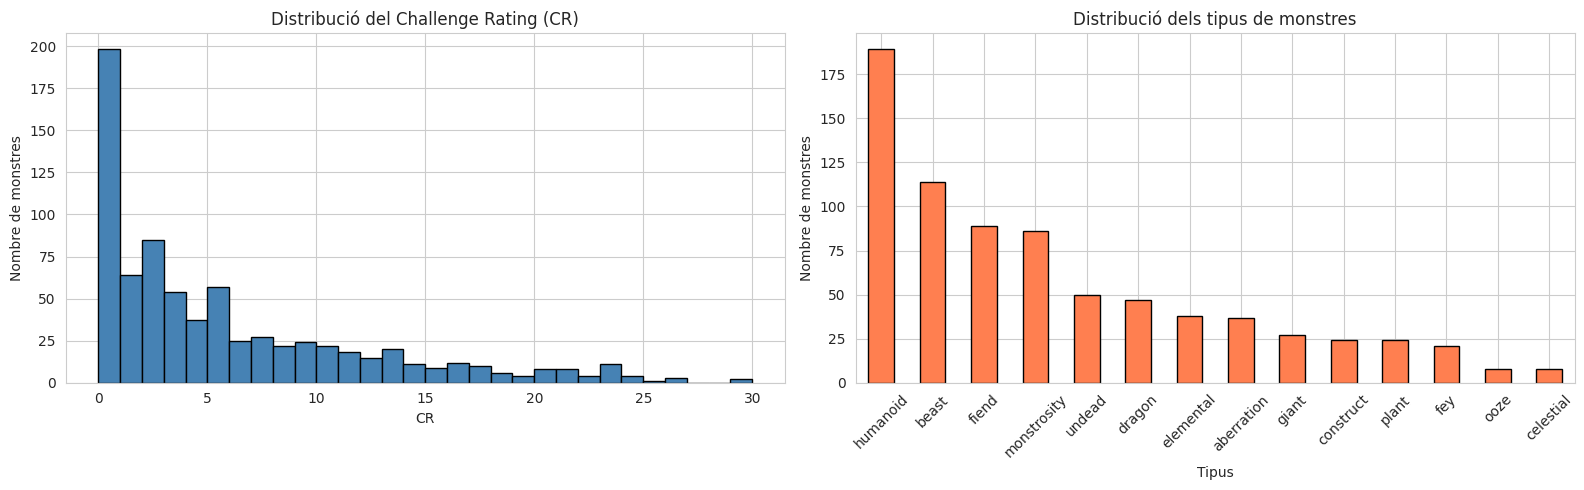

In [5]:
# Distribució del CR
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['cr'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribució del Challenge Rating (CR)')
axes[0].set_xlabel('CR')
axes[0].set_ylabel('Nombre de monstres')

# Tipus de monstres més comuns
def simplify_type(t):
    if pd.isna(t): return 'unknown'
    t = t.lower()
    for cat in ['humanoid','undead','beast','dragon','fiend','construct',
                'monstrosity','aberration','elemental','fey','giant','plant','ooze','celestial']:
        if cat in t: return cat
    return 'other'

df['type_simple'] = df['type'].apply(simplify_type)
type_counts = df['type_simple'].value_counts()
type_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribució dels tipus de monstres')
axes[1].set_xlabel('Tipus')
axes[1].set_ylabel('Nombre de monstres')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('static/img/eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

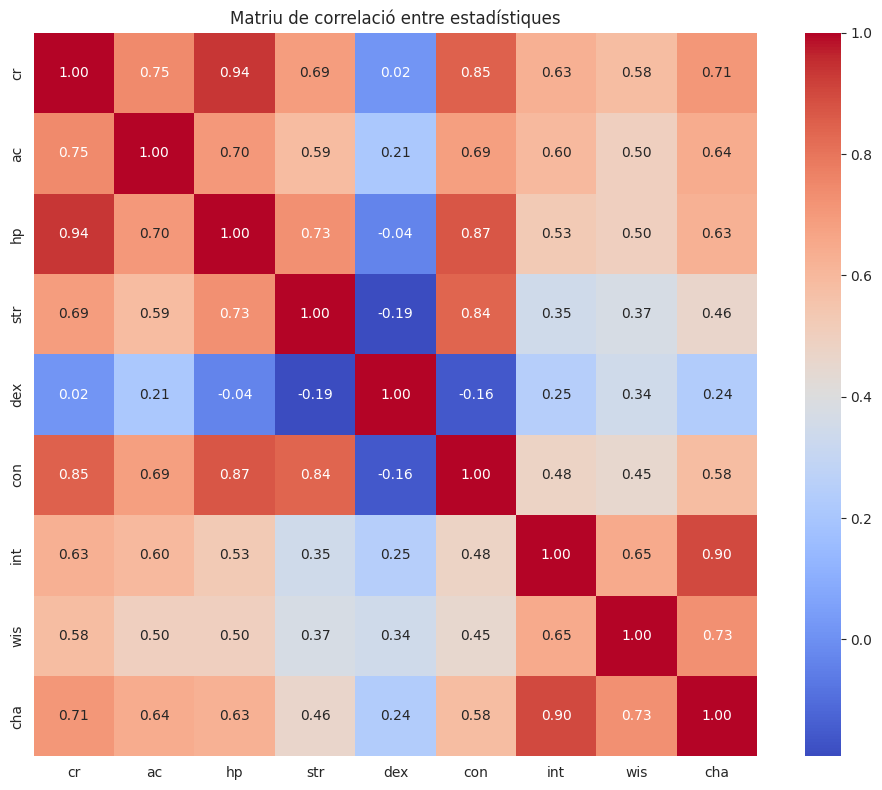

In [6]:
# Correlació entre estadístiques numèriques
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
corr_df = df[num_cols].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriu de correlació entre estadístiques')
plt.tight_layout()
plt.savefig('static/img/eda_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

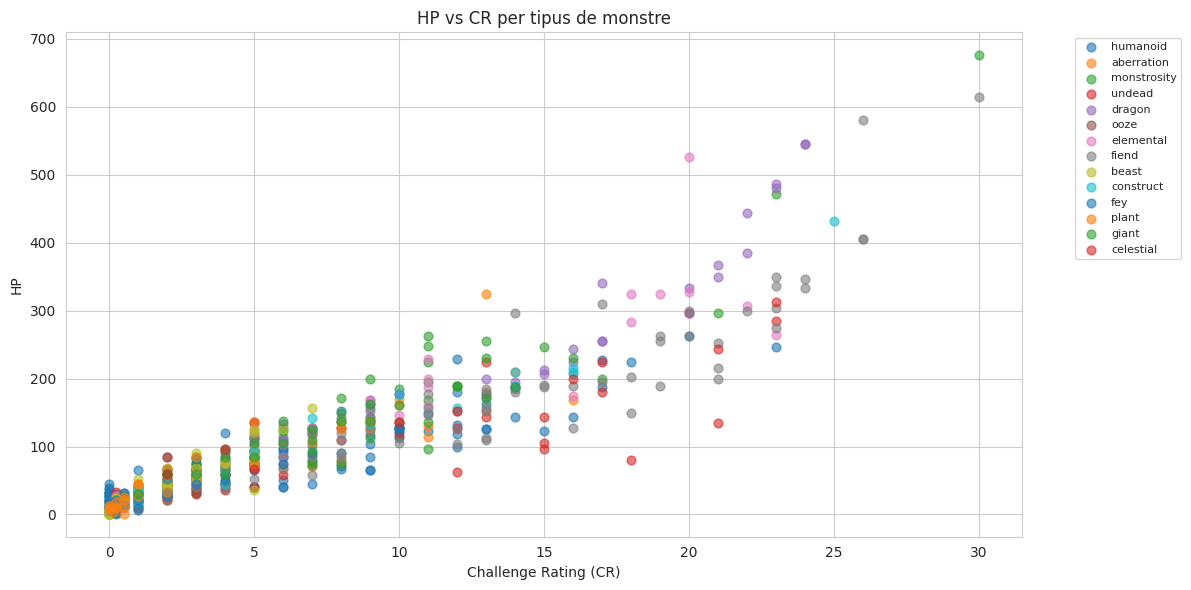

In [7]:
# HP vs CR per tipus
df_plot = df.dropna(subset=['cr','hp','type_simple'])
plt.figure(figsize=(12, 6))
for t in df_plot['type_simple'].unique():
    subset = df_plot[df_plot['type_simple'] == t]
    plt.scatter(subset['cr'], subset['hp'], label=t, alpha=0.6, s=40)
plt.xlabel('Challenge Rating (CR)')
plt.ylabel('HP')
plt.title('HP vs CR per tipus de monstre')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('static/img/eda_hp_cr.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Preprocessament de dades

In [8]:
# Dataset net: només files amb estadístiques completes
stat_cols = ['str', 'dex', 'con', 'int', 'wis', 'cha']
df_clean = df.dropna(subset=['cr', 'ac', 'hp'] + stat_cols).copy()
df_clean = df_clean.drop_duplicates(subset=['name'])

# Encoders per variables categòriques
le_type = LabelEncoder()
le_size = LabelEncoder()
df_clean['type_enc'] = le_type.fit_transform(df_clean['type_simple'])
df_clean['size_enc'] = le_size.fit_transform(df_clean['size'].astype(str))

# Bracket de dificultat per CR
def cr_bracket(cr):
    if cr <= 4: return 'Fàcil'
    elif cr <= 10: return 'Mitjà'
    else: return 'Difícil'

df_clean['cr_bracket'] = df_clean['cr'].apply(cr_bracket)

# Llegendari binari
df_clean['is_legendary'] = df_clean['legendary'].notna().astype(int)

scaler = StandardScaler()

print(f'Dataset net: {df_clean.shape[0]} monstres')
print(f'Distribució brackets CR:\n{df_clean["cr_bracket"].value_counts()}')
print(f'\nLlegendaris: {df_clean["is_legendary"].sum()} / {len(df_clean)}')

Dataset net: 401 monstres
Distribució brackets CR:
cr_bracket
Fàcil      260
Mitjà       84
Difícil     57
Name: count, dtype: int64

Llegendaris: 35 / 401


## 5. Model 1: Naive Bayes — Classificació del tipus de monstre

In [9]:

# Features: estadístiques numèriques + AC + HP + CR
features_nb = ['cr', 'ac', 'hp'] + stat_cols
X_nb = df_clean[features_nb].values
y_nb = df_clean['type_enc'].values

X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42
)

nb_model = GaussianNB()
nb_model.fit(X_nb_train, y_nb_train)
y_nb_pred = nb_model.predict(X_nb_test)

print('=== Naive Bayes — Classificació del tipus de monstre ===')
print(f'Accuracy: {accuracy_score(y_nb_test, y_nb_pred):.4f}')
print('\nInforme de classificació:')
labels_present = np.unique(np.concatenate([y_nb_test, y_nb_pred]))
print(classification_report(y_nb_test, y_nb_pred,
      labels=labels_present,
      target_names=le_type.classes_[labels_present], zero_division=0))


=== Naive Bayes — Classificació del tipus de monstre ===
Accuracy: 0.5679

Informe de classificació:
              precision    recall  f1-score   support

  aberration       0.00      0.00      0.00         2
       beast       0.82      0.90      0.86        20
   celestial       0.67      0.67      0.67         3
      dragon       0.75      0.90      0.82        10
   elemental       0.00      0.00      0.00         6
         fey       0.00      0.00      0.00         1
       fiend       0.20      0.17      0.18         6
       giant       0.17      0.33      0.22         3
    humanoid       0.45      0.83      0.59        12
 monstrosity       1.00      0.23      0.38        13
        ooze       1.00      1.00      1.00         1
       plant       0.00      0.00      0.00         0
      undead       0.33      0.25      0.29         4

    accuracy                           0.57        81
   macro avg       0.41      0.41      0.38        81
weighted avg       0.60      0.57

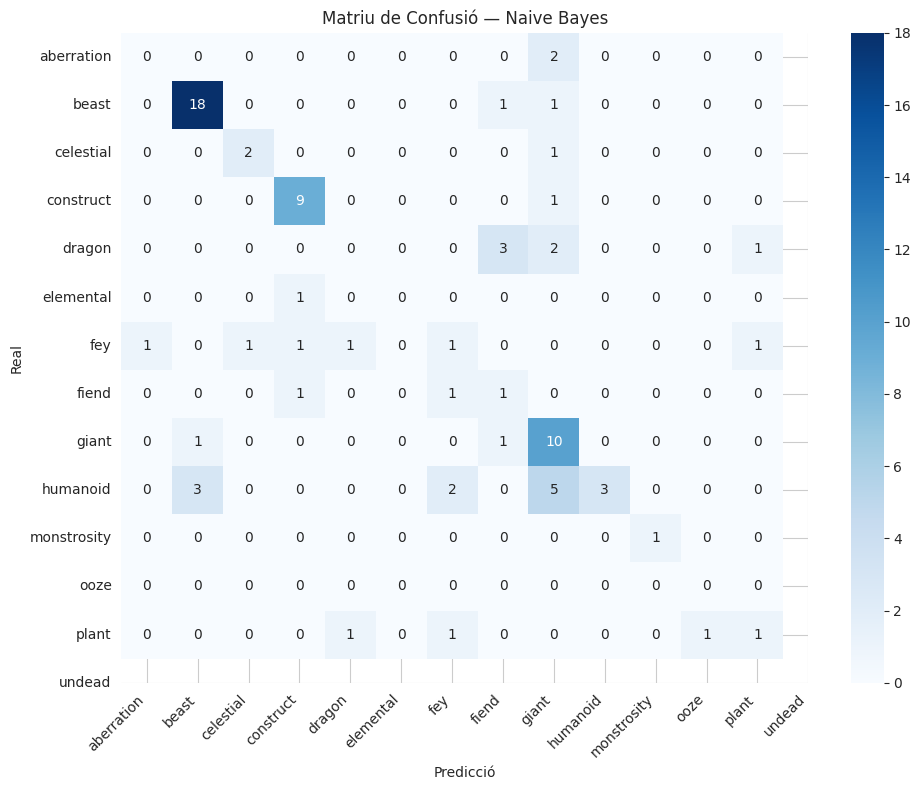

Model guardat.


In [10]:
# Matriu de confusió Naive Bayes
cm_nb = confusion_matrix(y_nb_test, y_nb_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_type.classes_, yticklabels=le_type.classes_)
plt.title('Matriu de Confusió — Naive Bayes')
plt.xlabel('Predicció')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('static/img/cm_naive_bayes.png', dpi=100, bbox_inches='tight')
plt.show()

# Guardar model
pickle.dump(nb_model, open('models/naive_bayes.pkl', 'wb'))
print('Model guardat.')

## 6. Model 2: Arbre de Decisions — Bracket de dificultat (CR)

In [11]:
features_dt = ['ac', 'hp'] + stat_cols
le_bracket = LabelEncoder()
X_dt = df_clean[features_dt].values
y_dt = le_bracket.fit_transform(df_clean['cr_bracket'].values)

X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_leaf=3)
dt_model.fit(X_dt_train, y_dt_train)
y_dt_pred = dt_model.predict(X_dt_test)

print('=== Arbre de Decisions — Bracket de dificultat ===')
print(f'Accuracy: {accuracy_score(y_dt_test, y_dt_pred):.4f}')
print('\nInforme de classificació:')
print(classification_report(y_dt_test, y_dt_pred,
      target_names=le_bracket.classes_, zero_division=0))

=== Arbre de Decisions — Bracket de dificultat ===
Accuracy: 0.9136

Informe de classificació:
              precision    recall  f1-score   support

     Difícil       0.69      1.00      0.81        11
       Fàcil       0.96      0.98      0.97        53
       Mitjà       1.00      0.65      0.79        17

    accuracy                           0.91        81
   macro avg       0.88      0.88      0.86        81
weighted avg       0.93      0.91      0.91        81



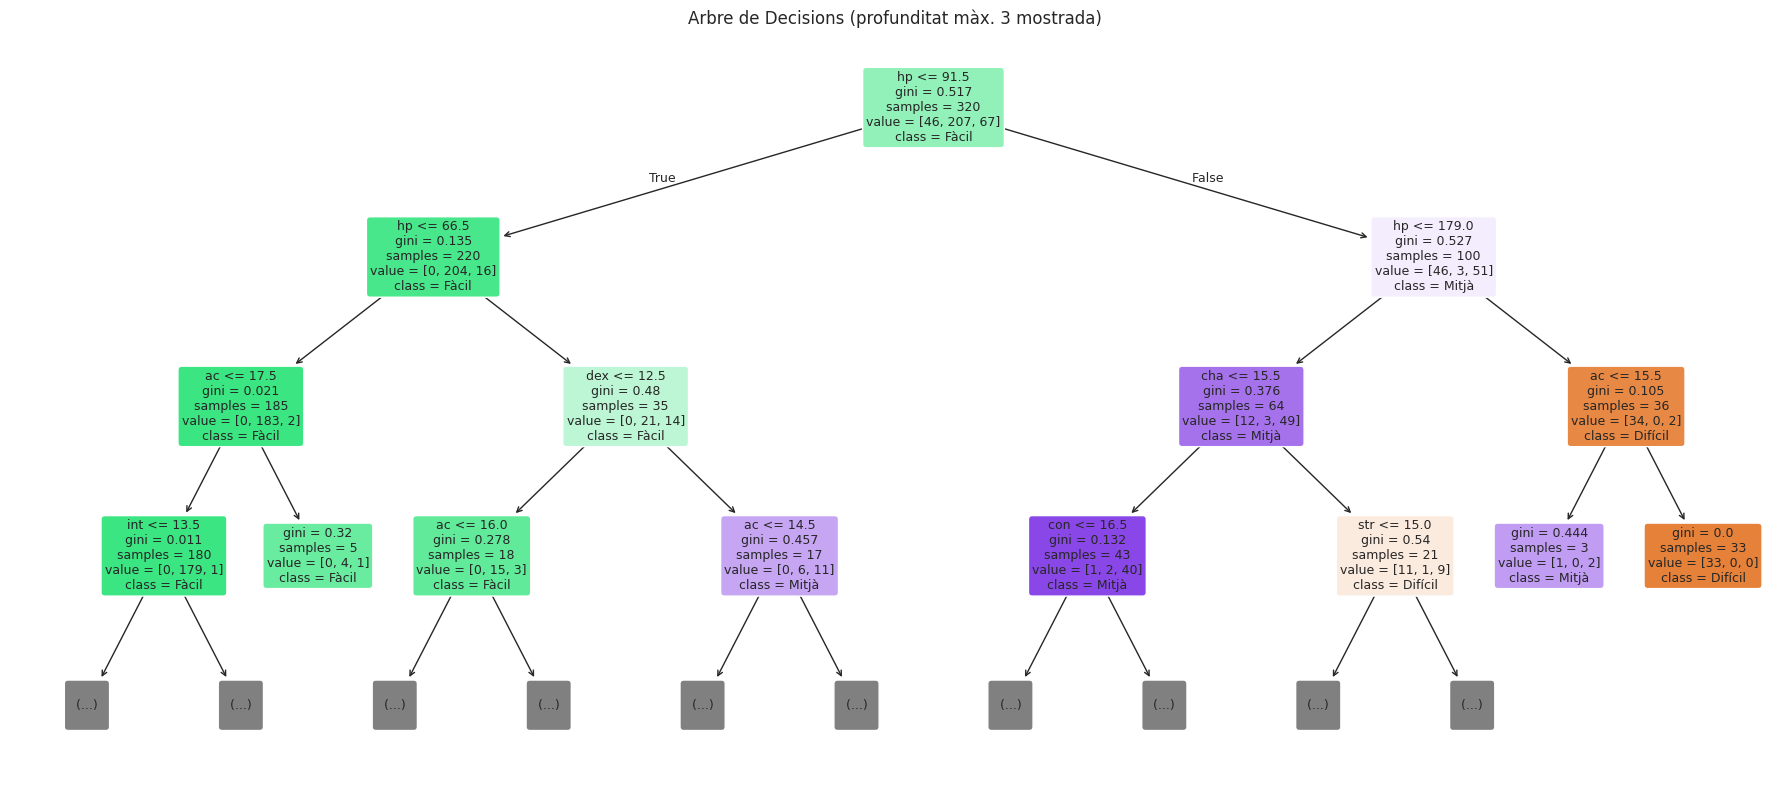

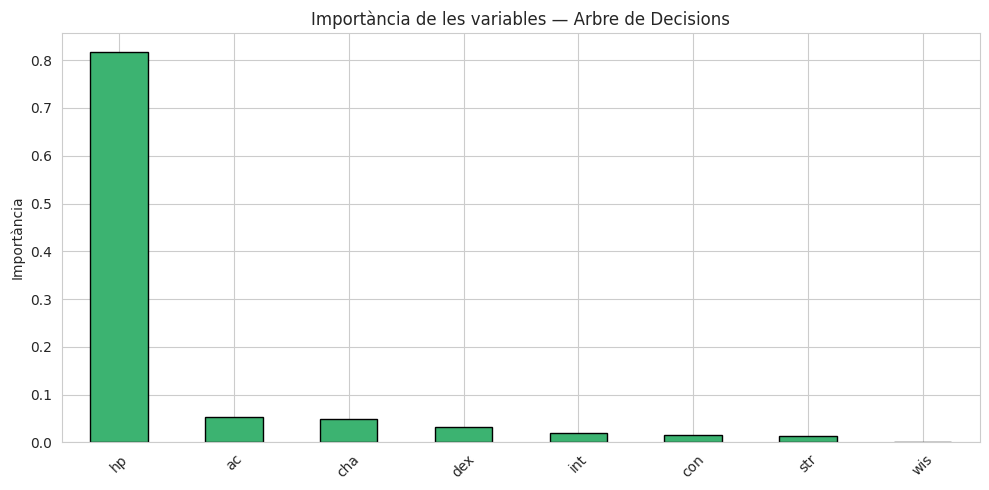

Model guardat.


In [12]:
# Visualització de l'arbre (primeres capes)
plt.figure(figsize=(18, 8))
plot_tree(dt_model, max_depth=3, feature_names=features_dt,
          class_names=le_bracket.classes_, filled=True, rounded=True, fontsize=9)
plt.title('Arbre de Decisions (profunditat màx. 3 mostrada)')
plt.tight_layout()
plt.savefig('static/img/decision_tree.png', dpi=80, bbox_inches='tight')
plt.show()

# Importància de les features
feat_imp = pd.Series(dt_model.feature_importances_, index=features_dt).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Importància de les variables — Arbre de Decisions')
plt.ylabel('Importància')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('static/img/dt_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

pickle.dump(dt_model, open('models/decision_tree.pkl', 'wb'))
print('Model guardat.')

## 7. Model 3: K-Nearest Neighbors (KNN) — Bracket de dificultat (CR)

In [13]:
features_knn = ['ac', 'hp'] + stat_cols
X_knn = df_clean[features_knn].values
y_knn = le_bracket.transform(df_clean['cr_bracket'].values)

X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn
)

scaler_knn = StandardScaler()
X_knn_train_sc = scaler_knn.fit_transform(X_knn_train)
X_knn_test_sc = scaler_knn.transform(X_knn_test)

# Trobar el millor valor de k amb validació creuada
k_values = range(1, 21)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
             X_knn_train_sc, y_knn_train, cv=5).mean() for k in k_values]
best_k = k_values[np.argmax(cv_scores)]
print(f'Millor k trobat: {best_k} (CV accuracy: {max(cv_scores):.4f})')

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_knn_train_sc, y_knn_train)
y_knn_pred = knn_model.predict(X_knn_test_sc)

print('\n=== KNN — Bracket de dificultat ===')
print(f'Accuracy: {accuracy_score(y_knn_test, y_knn_pred):.4f}')
print('\nInforme de classificació:')
print(classification_report(y_knn_test, y_knn_pred,
      target_names=le_bracket.classes_, zero_division=0))

Millor k trobat: 4 (CV accuracy: 0.8719)

=== KNN — Bracket de dificultat ===
Accuracy: 0.8519

Informe de classificació:
              precision    recall  f1-score   support

     Difícil       0.73      1.00      0.85        11
       Fàcil       0.89      0.94      0.92        53
       Mitjà       0.80      0.47      0.59        17

    accuracy                           0.85        81
   macro avg       0.81      0.80      0.79        81
weighted avg       0.85      0.85      0.84        81



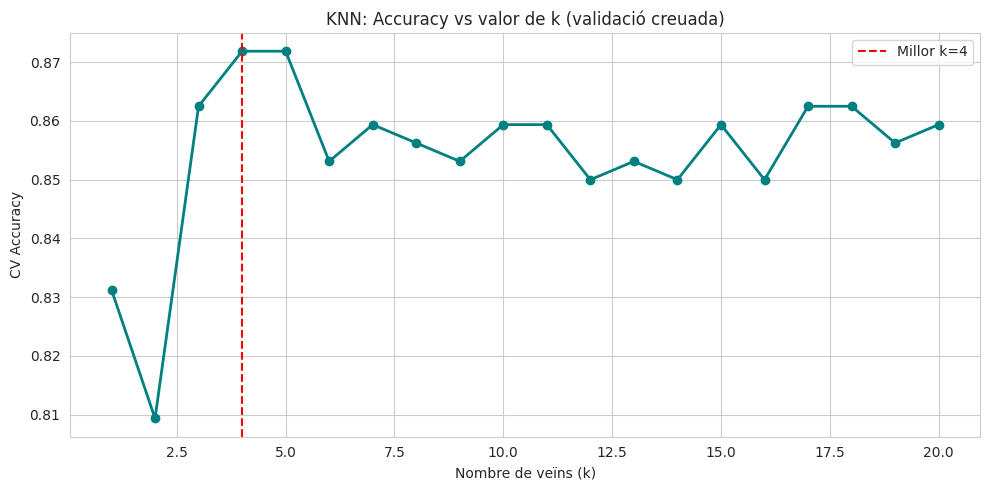

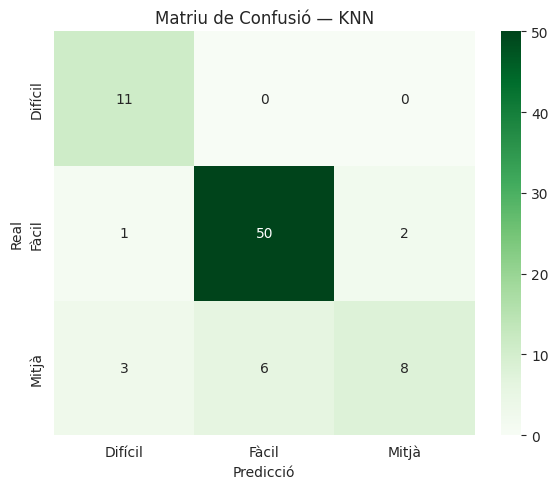

Model guardat.


In [14]:
# Gràfic: accuracy per valor de k
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), cv_scores, marker='o', color='teal', lw=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Millor k={best_k}')
plt.xlabel('Nombre de veïns (k)')
plt.ylabel('CV Accuracy')
plt.title('KNN: Accuracy vs valor de k (validació creuada)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('static/img/knn_k_search.png', dpi=100, bbox_inches='tight')
plt.show()

# Matriu de confusió KNN
cm_knn = confusion_matrix(y_knn_test, y_knn_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_bracket.classes_, yticklabels=le_bracket.classes_)
plt.title('Matriu de Confusió — KNN')
plt.xlabel('Predicció')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('static/img/cm_knn.png', dpi=100, bbox_inches='tight')
plt.show()

pickle.dump((knn_model, scaler_knn), open('models/knn.pkl', 'wb'))
print('Model guardat.')

## 8. Model 4: Perceptró — Classificació binària (llegendari?)

In [15]:
features_perc = ['cr', 'ac', 'hp'] + stat_cols
X_perc = df_clean[features_perc].values
y_perc = df_clean['is_legendary'].values

X_perc_train, X_perc_test, y_perc_train, y_perc_test = train_test_split(
    X_perc, y_perc, test_size=0.2, random_state=42, stratify=y_perc
)

scaler_perc = StandardScaler()
X_perc_train_sc = scaler_perc.fit_transform(X_perc_train)
X_perc_test_sc = scaler_perc.transform(X_perc_test)

perc_model = Perceptron(max_iter=5000, random_state=42, eta0=0.1, tol=1e-4)
perc_model.fit(X_perc_train_sc, y_perc_train)
y_perc_pred = perc_model.predict(X_perc_test_sc)

print('=== Perceptró — Llegendari? ===')
print(f'Accuracy: {accuracy_score(y_perc_test, y_perc_pred):.4f}')
print('\nInforme de classificació:')
print(classification_report(y_perc_test, y_perc_pred,
      target_names=['No llegendari', 'Llegendari'], zero_division=0))

=== Perceptró — Llegendari? ===
Accuracy: 0.9383

Informe de classificació:
               precision    recall  f1-score   support

No llegendari       1.00      0.93      0.97        74
   Llegendari       0.58      1.00      0.74         7

     accuracy                           0.94        81
    macro avg       0.79      0.97      0.85        81
 weighted avg       0.96      0.94      0.95        81



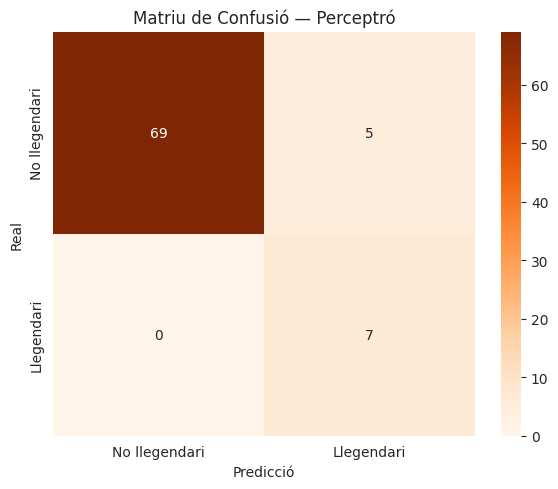

Model guardat.


In [16]:
cm_perc = confusion_matrix(y_perc_test, y_perc_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No llegendari', 'Llegendari'],
            yticklabels=['No llegendari', 'Llegendari'])
plt.title('Matriu de Confusió — Perceptró')
plt.xlabel('Predicció')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('static/img/cm_perceptron.png', dpi=100, bbox_inches='tight')
plt.show()

pickle.dump((perc_model, scaler_perc), open('models/perceptron.pkl', 'wb'))
print('Model guardat.')

## 9. Model 5: Xarxa Neuronal (MLP) — Classificació de la mida

In [17]:
features_nn = ['cr', 'ac', 'hp'] + stat_cols
X_nn = df_clean[features_nn].values
y_nn = df_clean['size_enc'].values

X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42, stratify=y_nn
)

scaler_nn = StandardScaler()
X_nn_train_sc = scaler_nn.fit_transform(X_nn_train)
X_nn_test_sc = scaler_nn.transform(X_nn_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001
)
nn_model.fit(X_nn_train_sc, y_nn_train)
y_nn_pred = nn_model.predict(X_nn_test_sc)

print('=== Xarxa Neuronal (MLP) — Mida del monstre ===')
print(f'Accuracy: {accuracy_score(y_nn_test, y_nn_pred):.4f}')
print(f'Capes ocultes: {nn_model.hidden_layer_sizes}')
print(f'Iteracions fins convergència: {nn_model.n_iter_}')
print('\nInforme de classificació:')
print(classification_report(y_nn_test, y_nn_pred,
      target_names=le_size.classes_, zero_division=0))

=== Xarxa Neuronal (MLP) — Mida del monstre ===
Accuracy: 0.5679
Capes ocultes: (128, 64, 32)
Iteracions fins convergència: 30

Informe de classificació:
              precision    recall  f1-score   support

  Gargantuan       1.00      0.33      0.50         3
        Huge       0.20      0.12      0.15         8
       Large       0.52      0.52      0.52        25
      Medium       0.61      0.82      0.70        34
       Small       0.00      0.00      0.00         6
        Tiny       0.75      0.60      0.67         5

    accuracy                           0.57        81
   macro avg       0.51      0.40      0.42        81
weighted avg       0.52      0.57      0.53        81



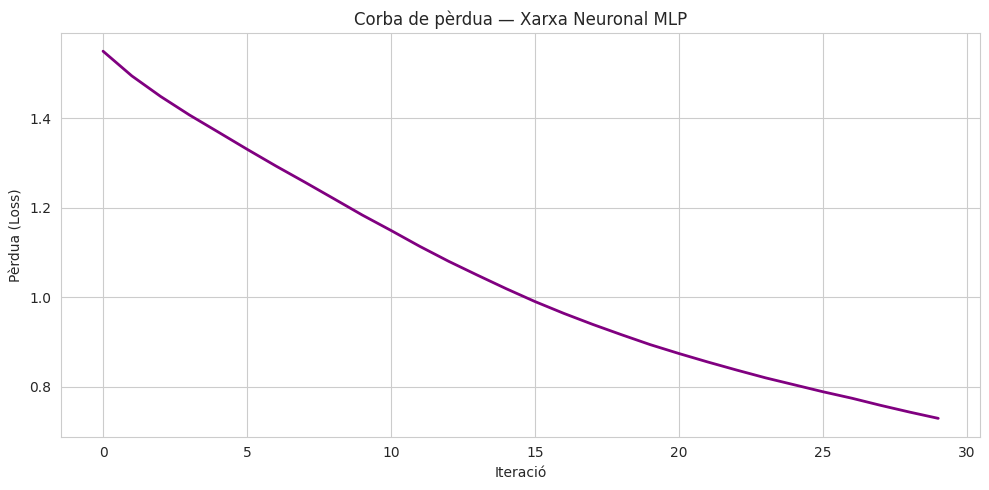

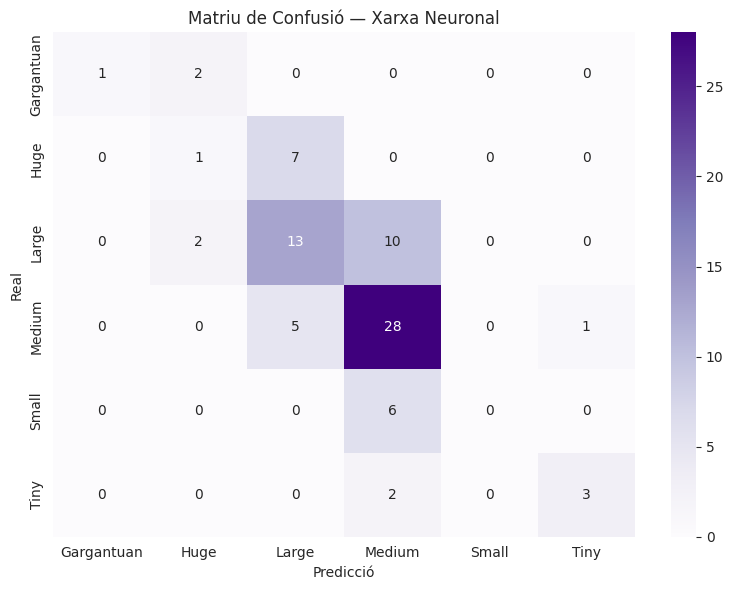

Model guardat.


In [18]:
# Corba de pèrdua
plt.figure(figsize=(10, 5))
plt.plot(nn_model.loss_curve_, color='purple', lw=2)
plt.xlabel('Iteració')
plt.ylabel('Pèrdua (Loss)')
plt.title('Corba de pèrdua — Xarxa Neuronal MLP')
plt.grid(True)
plt.tight_layout()
plt.savefig('static/img/nn_loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Matriu de confusió
cm_nn = confusion_matrix(y_nn_test, y_nn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_size.classes_, yticklabels=le_size.classes_)
plt.title('Matriu de Confusió — Xarxa Neuronal')
plt.xlabel('Predicció')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('static/img/cm_neural_network.png', dpi=100, bbox_inches='tight')
plt.show()

pickle.dump((nn_model, scaler_nn), open('models/neural_network.pkl', 'wb'))
print('Model guardat.')

## 10. Comparació global dels models

=== Resum d'accuracy per model ===
  Naive Bayes (tipus)                   : 0.5679 (56.8%)
  Arbre Decisions (CR bracket)          : 0.9136 (91.4%)
  KNN (CR bracket)                      : 0.8519 (85.2%)
  Perceptró (llegendari)                : 0.9383 (93.8%)
  Xarxa Neuronal (mida)                 : 0.5679 (56.8%)


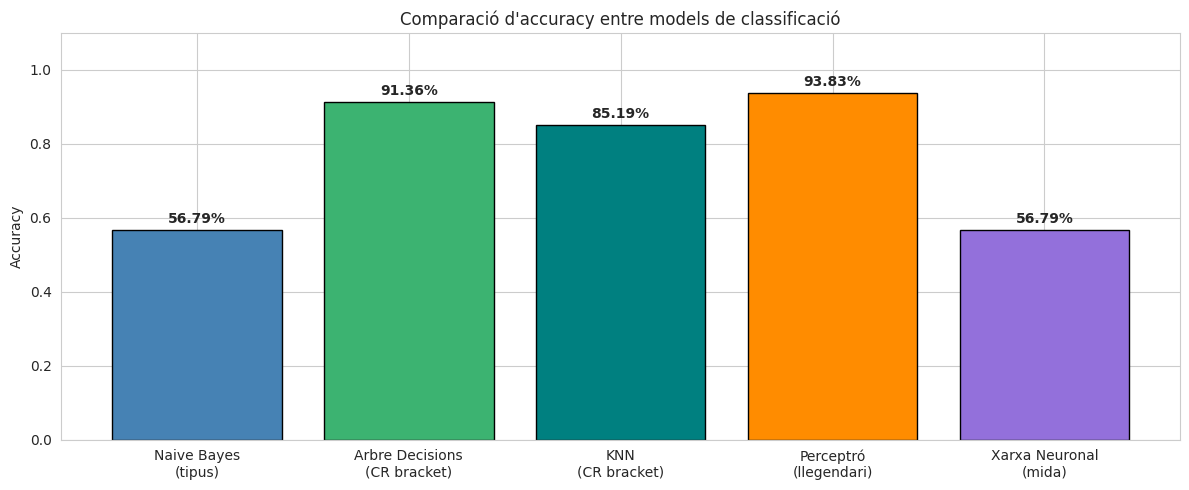

In [19]:
results = {
    'Naive Bayes\n(tipus)':       accuracy_score(y_nb_test,   y_nb_pred),
    'Arbre Decisions\n(CR bracket)': accuracy_score(y_dt_test, y_dt_pred),
    'KNN\n(CR bracket)':          accuracy_score(y_knn_test,  y_knn_pred),
    'Perceptró\n(llegendari)':    accuracy_score(y_perc_test, y_perc_pred),
    'Xarxa Neuronal\n(mida)':     accuracy_score(y_nn_test,   y_nn_pred),
}

print("=== Resum d'accuracy per model ===")
for model, acc in results.items():
    print(f'  {model.replace(chr(10)," "):38s}: {acc:.4f} ({acc*100:.1f}%)')

plt.figure(figsize=(12, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['steelblue','mediumseagreen','teal','darkorange','mediumpurple'],
               edgecolor='black')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2%}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title("Comparació d'accuracy entre models de classificació")
plt.tight_layout()
plt.savefig('static/img/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# Guardar encoders i scalers per a l'app Flask
preprocessors = {
    'le_type': le_type,
    'le_size': le_size,
    'le_bracket': le_bracket,
    'features_nb': features_nb,
    'features_dt': features_dt,
    'features_knn': features_knn,
    'features_perc': features_perc,
    'features_nn': features_nn,
}
pickle.dump(preprocessors, open('models/preprocessors.pkl', 'wb'))
print('Preprocessors guardats. El notebook ha acabat correctament.')

Preprocessors guardats. El notebook ha acabat correctament.


## 11. Conclusions

- **Naive Bayes** ha ofert un rendiment raonable per classificar el tipus de monstre tot i la superposició entre categories similars (humanoid, fiend...).
- **Arbre de Decisions** ha funcionat molt bé per predir el bracket de dificultat, ja que existeix una relació clara entre HP/AC/stats i el CR.
- **KNN** aplicat al mateix problema que l'arbre permet comparar les dues aproximacions: mentre l'arbre usa regles explícites, KNN basa les prediccions en la similitud entre monstres. La cerca del millor k per validació creuada és un exemple de tuning de hiperparàmetres.
- **Perceptró** aconsegueix una bona accuracy en la classificació binària de llegendaris, tot i que el dataset és molt desequilibrat (pocs llegendaris).
- **Xarxa Neuronal (MLP)** classifica raonablement la mida del monstre, però amb certa dificultat en les categories menys representades (Tiny, Gargantuan).

En general, l'arbre de decisions i el KNN obtenen resultats similars en el bracket de CR, confirmant que les estadístiques dels monstres de D&D segueixen patrons suficientment regulars perquè ambdós models els capturen bé.